# EDA


In [9]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

pd.set_option("display.max_columns", 20)
RANDOM_SEED = 42


# Check Dataset

In [ ]:
def find_dataset_dir():
    env_dir = os.environ.get("MASK_DATA_DIR")
    if env_dir:
        candidate = Path(env_dir).expanduser()
        if candidate.exists():
            return candidate

    candidates = [
        Path("data/raw"),
        Path.cwd() / "data/raw",
        Path.cwd().parent / "data/raw",
        Path.cwd().parent.parent / "data/raw",
        Path.cwd() / "../data/raw",
    ]

    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate

    return Path(os.environ.get("MASK_DATA_DIR", "data/raw")).expanduser()

DATA_DIR = find_dataset_dir()
EXPECTED_SPLITS = ["Train", "Validation", "Test"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Dataset path:", DATA_DIR.resolve())

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan di: {DATA_DIR.resolve()}\n"
        "Pastikan folder data/raw berisi Train/, Validation/, dan Test/ "
        "atau set environment variable MASK_DATA_DIR."
    )


Dataset path: /Users/paca/Documents/College/Semester 6/3. PCD/PROYEK/Klasifikasi-Penggunaan-Masker-Pada-Wajah/data/raw


## 1. Data Loading


In [21]:
records = []

for split in EXPECTED_SPLITS:
    split_dir = DATA_DIR / split
    if not split_dir.exists():
        continue

    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        for image_path in class_dir.iterdir():
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            records.append({
                "split": split,
                "label": class_dir.name,
                "path": str(image_path),
                "filename": image_path.name,
            })


In [22]:
files_df = pd.DataFrame(records)
files_df.head()

,split,label,path,filename
0,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,348.png
1,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,Augmented_147_8209775.png
2,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,Augmented_759_7226887.png
3,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,1810.png
4,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,Augmented_377_7487552.png


## 2. Struktur Dasar Data


In [23]:
print("Shape:", files_df.shape)
print("\nInfo:")
files_df.info()


Shape: (14786, 4)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 14786 entries, 0 to 14785
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   split     14786 non-null  str  
 1   label     14786 non-null  str  
 2   path      14786 non-null  str  
 3   filename  14786 non-null  str  
dtypes: str(4)
memory usage: 462.2 KB


In [24]:
files_df["label"].value_counts()


label
WithoutMask          5909
WithMask             5883
WithMaskIncorrect    2994
Name: count, dtype: int64

In [25]:
pd.crosstab(files_df["split"], files_df["label"])


label,WithMask,WithMaskIncorrect,WithoutMask
split,,,
Test,483,245,509
Train,5000,2545,5000
Validation,400,204,400


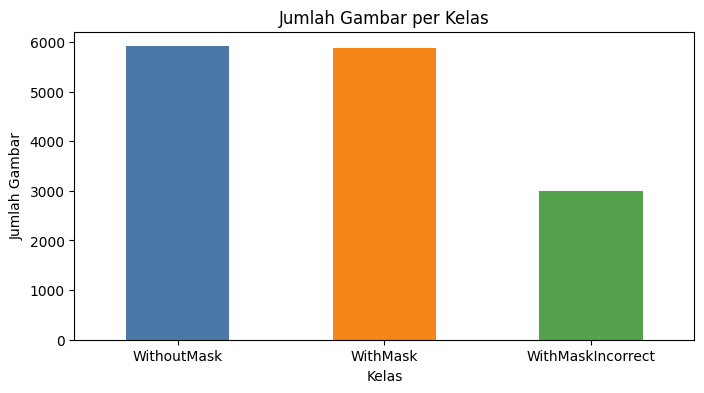

In [16]:
files_df["label"].value_counts().plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=0)
plt.show()


## 3. Metadata Sederhana


In [27]:
widths = []
heights = []
file_sizes = []

for path in files_df["path"]:
    img_path = Path(path)
    with Image.open(img_path) as img:
        width, height = img.size

    widths.append(width)
    heights.append(height)
    file_sizes.append(img_path.stat().st_size / 1024)

files_df["width"] = widths
files_df["height"] = heights
files_df["file_size_kb"] = file_sizes
files_df["aspect_ratio"] = files_df["width"] / files_df["height"]


In [28]:
files_df.head()

,split,label,path,filename,width,height,file_size_kb,aspect_ratio
0,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,348.png,62,62,7.980469,1.0
1,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,Augmented_147_8209775.png,224,224,32.861328,1.0
2,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,Augmented_759_7226887.png,224,224,36.082031,1.0
3,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,1810.png,115,115,23.738281,1.0
4,Train,WithMask,/Users/paca/Documents/College/Semester 6/3. PC...,Augmented_377_7487552.png,224,224,42.222656,1.0


In [29]:
files_df[["width", "height", "file_size_kb", "aspect_ratio"]].describe().round(2)


,width,height,file_size_kb,aspect_ratio
count,14786.00,14786.00,14786.00,14786.0
mean,147.83,147.83,27.07,1.0
std,57.04,57.04,14.54,0.0
min,25.00,25.00,0.22,1.0
25%,105.00,105.00,18.96,1.0
50%,128.00,128.00,23.05,1.0
75%,224.00,224.00,29.83,1.0
max,563.00,563.00,417.16,1.0


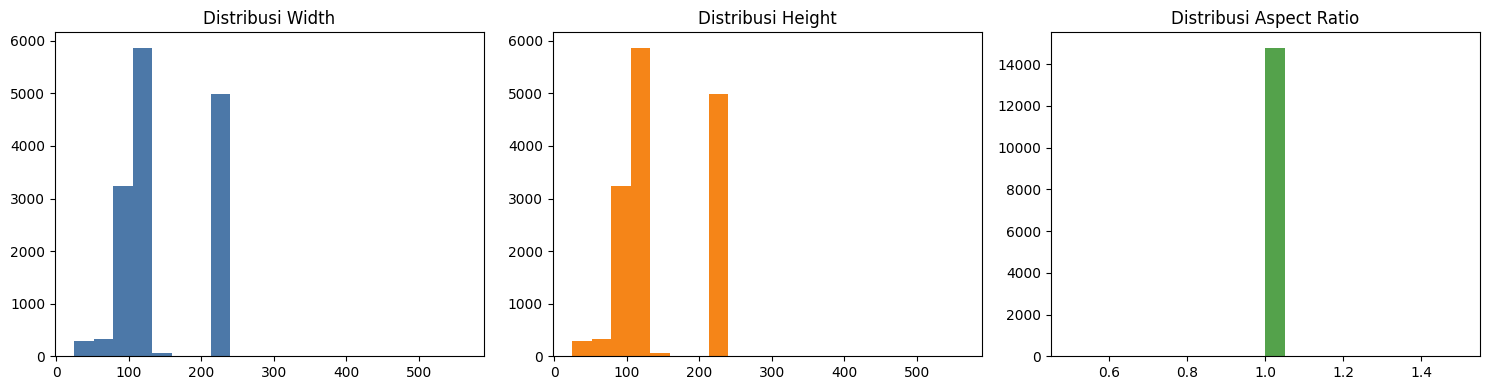

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(files_df["width"], bins=20, color="#4C78A8")
axes[0].set_title("Distribusi Width")

axes[1].hist(files_df["height"], bins=20, color="#F58518")
axes[1].set_title("Distribusi Height")

axes[2].hist(files_df["aspect_ratio"], bins=20, color="#54A24B")
axes[2].set_title("Distribusi Aspect Ratio")

plt.tight_layout()
plt.show()


## 4. Sample Images


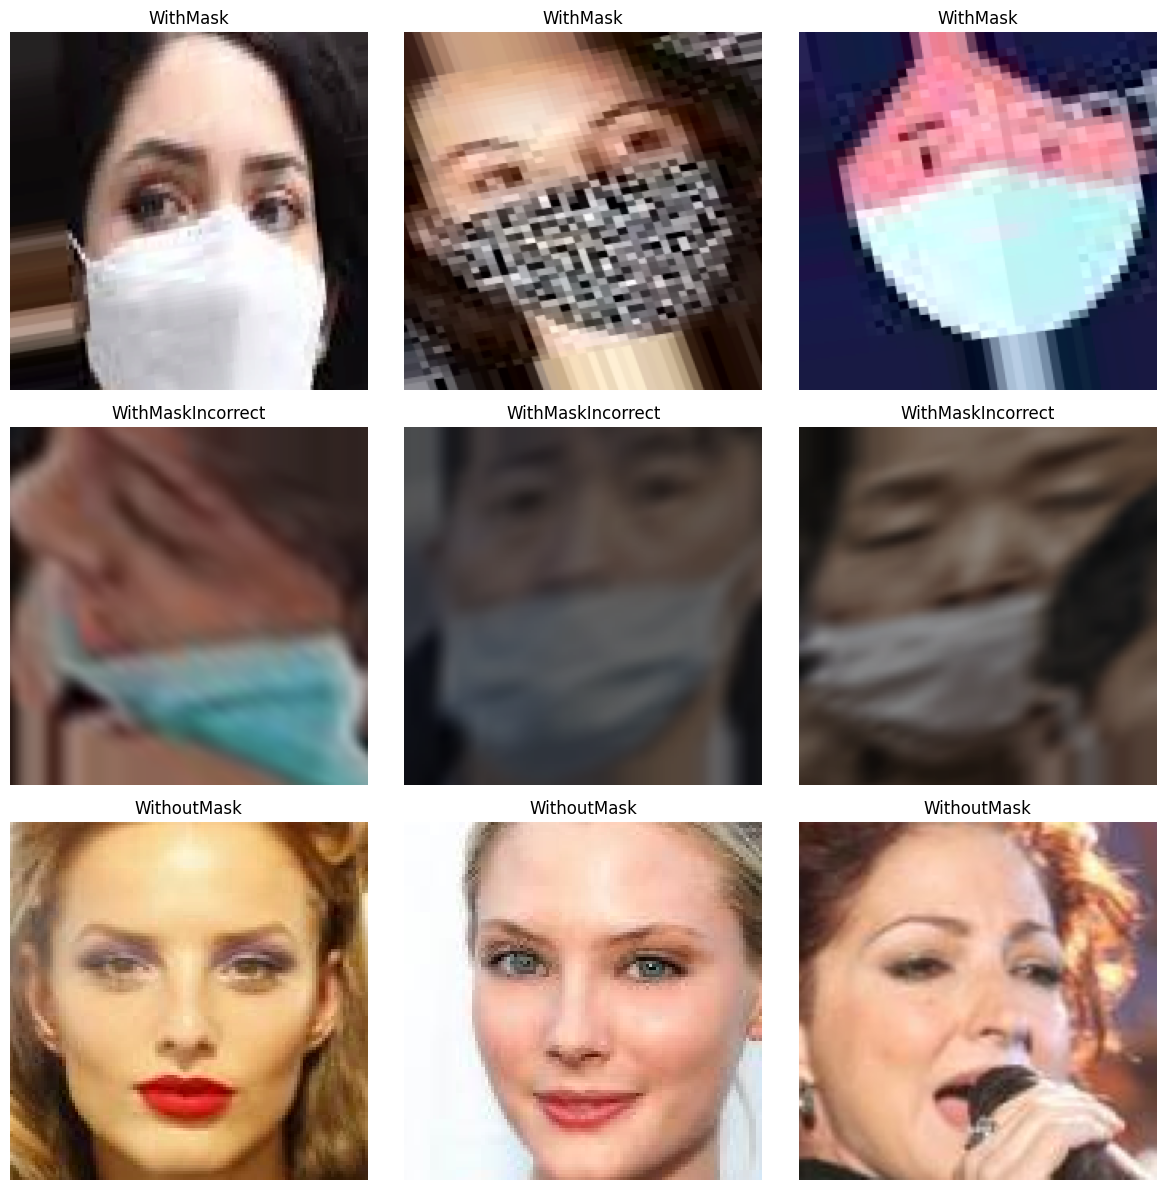

In [31]:
sample_split = "Train" if "Train" in files_df["split"].unique() else files_df["split"].iloc[0]
labels = sorted(files_df["label"].unique())
n_samples = 3

fig, axes = plt.subplots(len(labels), n_samples, figsize=(4 * n_samples, 4 * len(labels)))

if len(labels) == 1:
    axes = np.array([axes])

for i, label in enumerate(labels):
    sample_df = files_df[(files_df["split"] == sample_split) & (files_df["label"] == label)]
    sample_df = sample_df.sample(n=min(n_samples, len(sample_df)), random_state=RANDOM_SEED)

    for j in range(n_samples):
        axes[i, j].axis("off")

        if j >= len(sample_df):
            continue

        row = sample_df.iloc[j]
        axes[i, j].imshow(Image.open(row["path"]))
        axes[i, j].set_title(label)

plt.tight_layout()
plt.show()


## 5. Catatan EDA

- Apakah jumlah gambar per kelas seimbang?
- Apakah ukuran gambar relatif seragam?
- Apakah ada sampel gambar yang tampak aneh atau salah label?
- Dari hasil ini, preprocessing apa yang perlu dilakukan?
